### Libraries

In [1]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

### Data Preprocessing

In [2]:
#Loading Data
df = pd.read_csv("credit_card_fraud_10k.csv")
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [3]:
#Shape-Column
print(f"Shape: {df.shape}")
print(f"Columns: {np.array(df.columns)}")

Shape: (10000, 10)
Columns: ['transaction_id' 'amount' 'transaction_hour' 'merchant_category'
 'foreign_transaction' 'location_mismatch' 'device_trust_score'
 'velocity_last_24h' 'cardholder_age' 'is_fraud']


In [4]:
#Missing Values
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [5]:
#One Hot Encoding
df = pd.get_dummies(df, columns=["merchant_category"], dtype=int, drop_first=True)
df.head()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
0,1,84.47,22,0,0,66,3,40,0,1,0,0,0
1,2,541.82,3,1,0,87,1,64,0,0,0,0,1
2,3,237.01,17,0,0,49,1,61,0,0,0,1,0
3,4,164.33,4,0,1,72,3,34,0,0,0,1,0
4,5,30.53,15,0,0,79,0,44,0,0,1,0,0


### Model Training and Evaluation

In [6]:
#Train-Test Split and Scaling
X = df.drop(columns=["transaction_id", "is_fraud"])
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

X_train_normal = X_train[y_train == 0]

scaler = StandardScaler()

X_train_normal = scaler.fit_transform(X_train_normal)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
#Model Training
model = GaussianMixture(n_components=2, covariance_type="full", random_state=42)
model.fit(X_train_normal)

,"n_components n_components: int, default=1The number of mixture components.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None


In [8]:
train_scores = model.score_samples(X_train_normal)
test_scores = model.score_samples(X_test_scaled)

threshold = np.percentile(train_scores, 2)
print("Anomaly threshold:", threshold)

predicted_anomalies = test_scores < threshold
print("Number of detected anomalies:", predicted_anomalies.sum())

Anomaly threshold: -14.308461036631275
Number of detected anomalies: 61


In [9]:
#Model Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, predicted_anomalies.astype(int)))

print("\nClassification Report:")
print(classification_report(y_test, predicted_anomalies.astype(int), zero_division=0))

Confusion Matrix:
[[1918   52]
 [  21    9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1970
           1       0.15      0.30      0.20        30

    accuracy                           0.96      2000
   macro avg       0.57      0.64      0.59      2000
weighted avg       0.98      0.96      0.97      2000



In [10]:
results = X_test.copy()

results["actual_fraud"] = y_test.values
results["gmm_score"] = test_scores
results["gmm_anomaly"] = predicted_anomalies.astype(int)

print("\nResults:")
results.head()


Results:


,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel,actual_fraud,gmm_score,gmm_anomaly
9944,61.48,7,0,0,45,3,46,0,0,0,0,0,-5.903387,0
2601,10.06,20,0,0,25,3,26,0,0,1,0,0,-8.637601,0
342,34.24,5,0,0,84,1,21,1,0,0,0,0,-7.748055,0
3222,15.71,10,0,0,31,3,43,0,0,0,1,0,-6.858344,0
5216,105.84,17,0,0,26,1,21,0,0,0,0,0,-7.990698,0


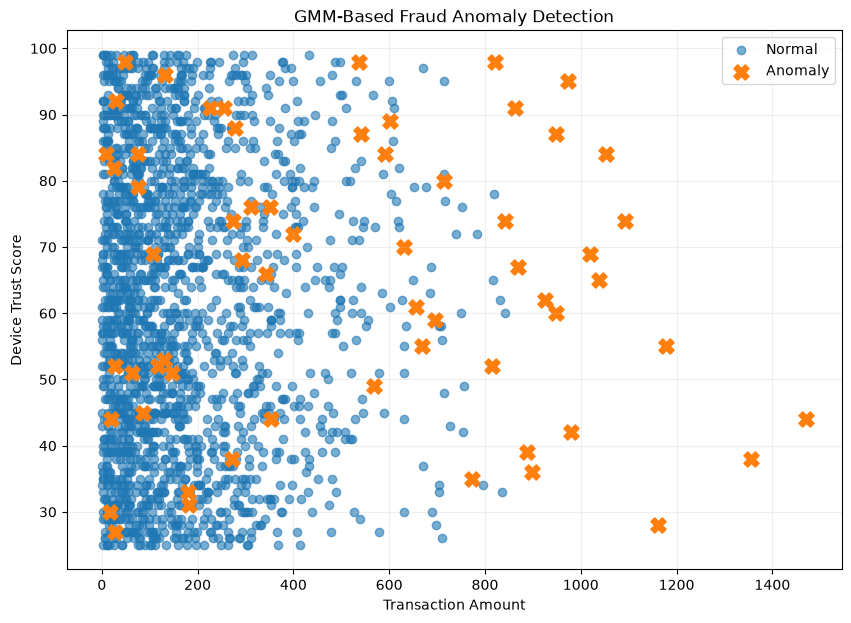

In [11]:
#Visualization
plt.figure(figsize=(10, 7))

# Normal points
plt.scatter(
    X_test.loc[~predicted_anomalies, "amount"],
    X_test.loc[~predicted_anomalies, "device_trust_score"],
    label="Normal",
    alpha=0.6
)

# Detected anomalies
plt.scatter(
    X_test.loc[predicted_anomalies, "amount"],
    X_test.loc[predicted_anomalies, "device_trust_score"],
    marker="X",
    s=120,
    label="Anomaly"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Device Trust Score")
plt.title("GMM-Based Fraud Anomaly Detection")
plt.legend()
plt.grid(alpha=0.2)

plt.show()